In [10]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# load in libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [12]:
# make the database connection 
connection = sqlite3.connect('../data/bookstore.db')

### Query 1: List the title, genre, and full author name for every book sold at a store in the Pacific region. Show each sale as its own row 

In [13]:
query1 = """
SELECT
    b.title,
    b.genre,
    a.author_first || ' ' || a.author_last AS author_name
FROM transactions t
JOIN stores s ON t.store_id = s.store_id
JOIN books b ON t.book_id = b.book_id
JOIN authors a ON b.author_id = a.author_id
WHERE s.store_region = 'Pacific'
"""

In [14]:
# execute the query
results1 = pd.read_sql_query(query1, connection)
results1

,title,genre,author_name
0,The Quiet Hours,Fiction,Ocean Vuong
1,The Quiet Hours,Fiction,Ocean Vuong
2,The Quiet Hours,Fiction,Ocean Vuong
3,The Quiet Hours Vol. 2,Fiction,Malcolm Gladwell
4,The Quiet Hours Vol. 2,Fiction,Malcolm Gladwell
...,...,...,...
1754,The Habit Code Vol. 2,Self-Help,Toni Morrison
1755,The Habit Code Vol. 2,Self-Help,Toni Morrison
1756,The Habit Code Vol. 2,Self-Help,Toni Morrison
1757,The Habit Code Vol. 2,Self-Help,Toni Morrison


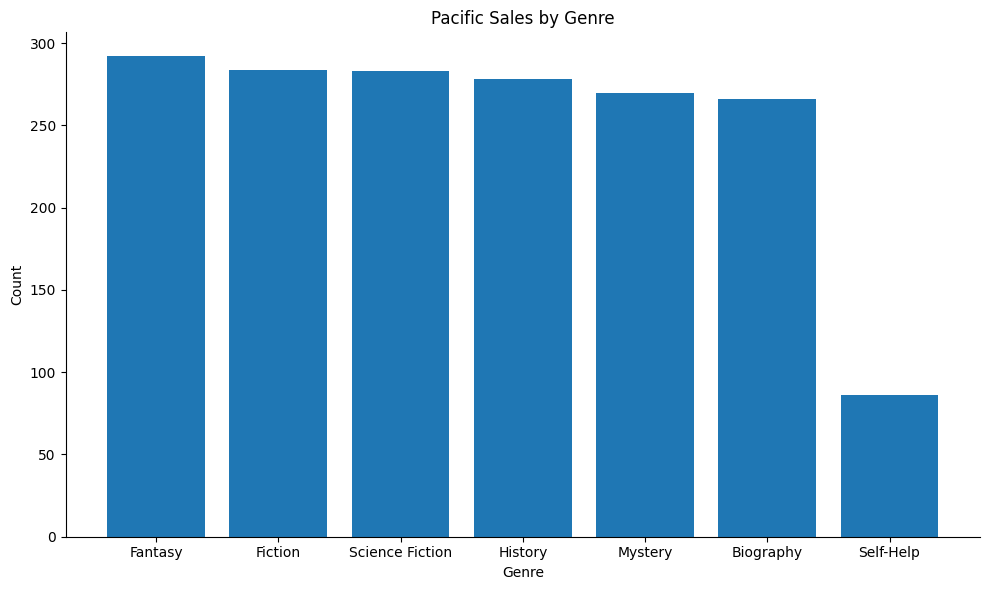

In [15]:
# create a visualization
genre_counts = results1['genre'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(genre_counts.index, genre_counts.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Pacific Sales by Genre')

plt.tight_layout()
plt.show()

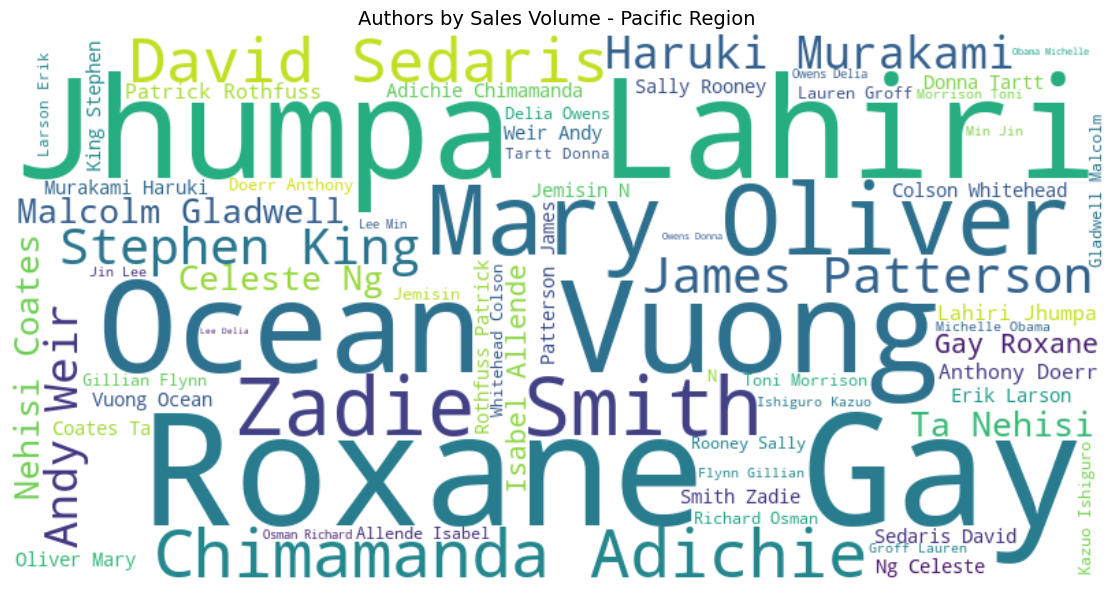

In [16]:
text = ' '.join(results1['author_name'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Authors by Sales Volume - Pacific Region', fontsize=14)
plt.tight_layout()
plt.show()

Discuss

### Query 2: Which genre generated the most total revenue across all transactions? Return the top 5 genres ranked by total sales, highest to lowest

In [17]:
query2 = """
select b.genre, sum(t.quantity*b.list_price*(1-(t.discount_percent/100.0))) as total_sales 
from transactions t join books b on t.book_id = b.book_id 
group by b.genre order by total_sales desc limit 5;"""

In [20]:
# execute the query
result2 = pd.read_sql_query(query2, connection)
result2

,genre,total_sales
0,Biography,40931.2815
1,History,39932.4300
2,Mystery,39479.0155
3,Science Fiction,38860.6780
4,Fiction,38200.6395


C:\Users\HMLAP01\AppData\Local\Temp\ipykernel_11904\1796552250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


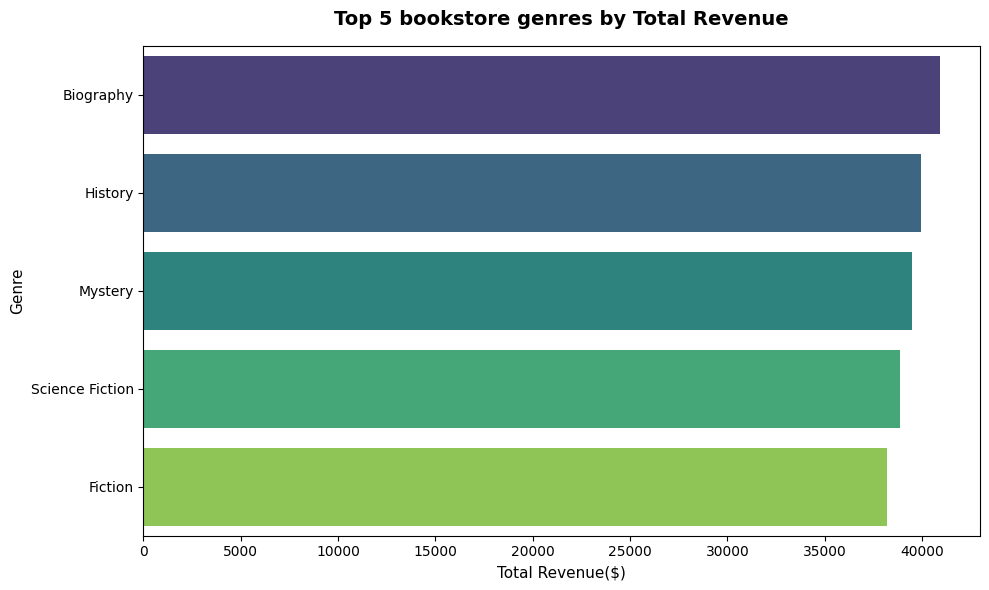

In [21]:
# create a visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(
    x="total_sales",
    y="genre",
    data=result2,
    palette='viridis'
)
plt.title("Top 5 bookstore genres by Total Revenue", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Revenue($)", fontsize=11)
plt.ylabel("Genre", fontsize=11)

plt.tight_layout()
plt.show()


Discuss

### Query 3: Find every member who has spent more than $200 in total across all their purchases. Return their full name, membership tier, and their total spend — but only include members who have made at least 3 separate transactions.

In [34]:
query3 = """
select m.member_first_name || '' || m.member_last_name as full_name,
m.member_tier, sum(t.quantity*b.list_price*(1-(t.discount_percent/100.0))) as total_spend 
from transactions t join members m on t.member_id = m.member_id join books b on t.book_id = b.book_id 
group by m.member_id, m.member_first_name, m.member_last_name, m.member_tier 
having sum(t.quantity*b.list_price*(1-t.discount_percent/100.0)) > 200;"""

In [35]:
# execute the 
result3 = pd.read_sql_query(query3, connection)
result3

,full_name,member_tier,total_spend
0,XanderDavis,Bronze,773.1385
1,LilaAllen,Bronze,666.4345
2,BlakeTaylor,Silver,897.3095
3,XanderWalker,Gold,1000.2515
4,BaileyJackson,Bronze,971.1155
...,...,...,...
295,JamesMoore,Bronze,879.2405
296,JamesKing,Gold,756.9665
297,NadiaLewis,Bronze,892.4745
298,GraceGreen,Platinum,572.5600


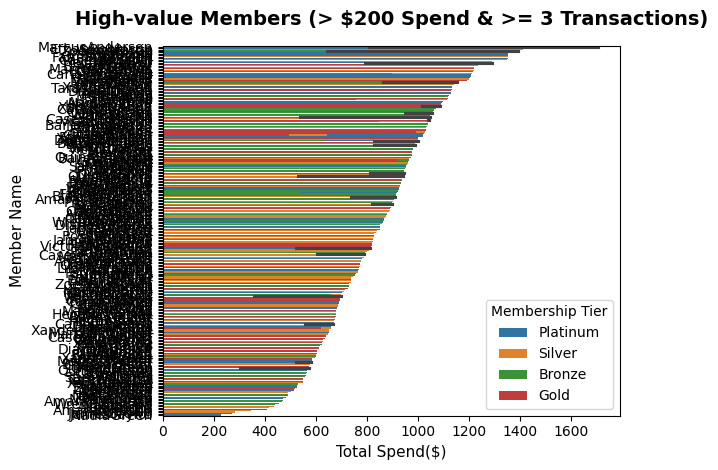

In [38]:
# create a visualization
sns.barplot(
    x="total_spend",
    y="full_name",
    hue="member_tier",
    data=result3.sort_values(by="total_spend", ascending=False),
    dodge=False
    
)
plt.title("High-value Members (> $200 Spend & >= 3 Transactions)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Spend($)", fontsize=11)
plt.ylabel("Member Name", fontsize=11)
plt.legend(title="Membership Tier")
plt.tight_layout()
plt.show()

Discuss

### Query 4: For each publisher, find the single book (by title) that has generated the most total revenue. Return the publisher name, book title, and that book's total revenue.

In [41]:
query4 = """
with book_revenues as (
    select p.publisher_name, 
    b.title, 
    sum(t.quantity * b.list_price *(1-t.discount_percent/100.0)) as total_revenue, 
    row_number() over (
        partition by p.publisher_id 
        order by sum(t.quantity*b.list_price*(1-t.discount_percent/100.0)) desc
    ) as ranking 
    from transactions t join books b on t.book_id = b.book_id join publishers p on b.publisher_id = p.publisher_id 
     group by p.publisher_id, b.book_id)
     select publisher_name, title, total_revenue from book_revenues where 
     ranking=1 order by total_revenue desc;"""

In [42]:
# execute the query

result4 = pd.read_sql_query(query4, connection)
result4

,publisher_name,title,total_revenue
0,HarperCollins,First Contact Vol. 4,2434.8960
1,Farrar Straus Giroux,Edge of Home Vol. 4,2389.3625
2,Penguin Random House,The Cold Case Vol. 3,2366.5995
3,Simon & Schuster,Edge of Home Vol. 8,2296.3865
4,Knopf,Orbit Zero Vol. 2,2279.4705
5,Hachette Book Group,Becoming More Vol. 3,2062.1310
6,Vintage Books,Becoming More Vol. 8,1974.5170
7,Scholastic,A Thousand Tomorrows Vol. 4,1842.4490
8,Bloomsbury,The Last Clue Vol. 2,1798.8915
9,Macmillan Publishers,Nova Protocol,1715.0065


C:\Users\HMLAP01\AppData\Local\Temp\ipykernel_11904\650505163.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


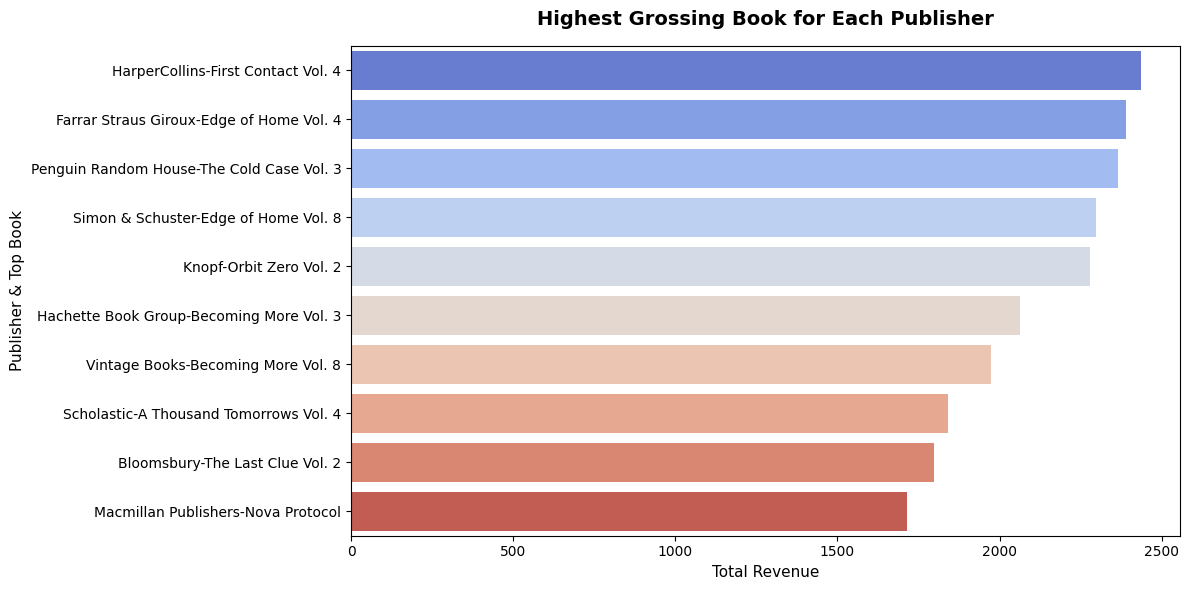

In [46]:
# create a visualization
result4['display_label'] = result4['publisher_name'] + "-" + result4['title']
plt.figure(figsize=(12,6))

sns.barplot(
    x="total_revenue",
    y="display_label",
    data=result4,
    palette="coolwarm"
)
plt.title("Highest Grossing Book for Each Publisher", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Revenue", fontsize=11)
plt.ylabel("Publisher & Top Book",fontsize=11)
plt.tight_layout()
plt.show()


Discuss

In [47]:
connection.close()